In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar detectando separador automáticamente
ruta = '/content/drive/MyDrive/Trabajo IT/Ingeniero_ML/ai4i2020.csv.xls'
df = pd.read_csv(ruta, sep=None, engine='python', encoding='utf-8')

# Ver resultado
print("Forma del dataset:", df.shape)
print("\nColumnas encontradas:")
print(df.columns.tolist())

Forma del dataset: (10000, 14)

Columnas encontradas:
['\ufeffUDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [11]:

df = df.rename(columns={
    'TWF': 'Falla_desgaste',
    'HDF': 'Falla_sobrecalentamiento',
    'PWF': 'Falla_potencia',
    'OSF': 'Falla_sobrecarga',
    'RNF': 'Falla_aleatoria'
})

print("Columnas del DataFrame después de renombrar:")
print(df.columns.tolist())
print("\nPrimeras 5 filas del DataFrame con las columnas renombradas:")
print(df.head())

Columnas del DataFrame después de renombrar:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Falla_desgaste', 'Falla_sobrecalentamiento', 'Falla_potencia', 'Falla_sobrecarga', 'Falla_aleatoria']

Primeras 5 filas del DataFrame con las columnas renombradas:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  \
0                    1551         42.8                0                0   
1                    1408         46.3        

In [8]:
# Renombrar columna con caracter extraño
df = df.rename(columns={'\ufeffUDI': 'UDI'})

# Información general
print("=== INFORMACIÓN DEL DATASET ===")
print(df.dtypes)
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)

=== INFORMACIÓN DEL DATASET ===
UDI                           int64
Product ID                   object
Type                         object
Air temperature [K]         float64
Process temperature [K]     float64
Rotational speed [rpm]        int64
Torque [Nm]                 float64
Tool wear [min]               int64
Machine failure               int64
Falla_desgaste                int64
Falla_sobrecalentamiento      int64
Falla_potencia                int64
Falla_sobrecarga              int64
Falla_aleatoria               int64
dtype: object

=== VALORES NULOS ===
UDI                         0
Product ID                  0
Type                        0
Air temperature [K]         0
Process temperature [K]     0
Rotational speed [rpm]      0
Torque [Nm]                 0
Tool wear [min]             0
Machine failure             0
Falla_desgaste              0
Falla_sobrecalentamiento    0
Falla_potencia              0
Falla_sobrecarga            0
Falla_aleatoria             0
dtype: 

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Falla_desgaste,Falla_sobrecalentamiento,Falla_potencia,Falla_sobrecarga,Falla_aleatoria
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


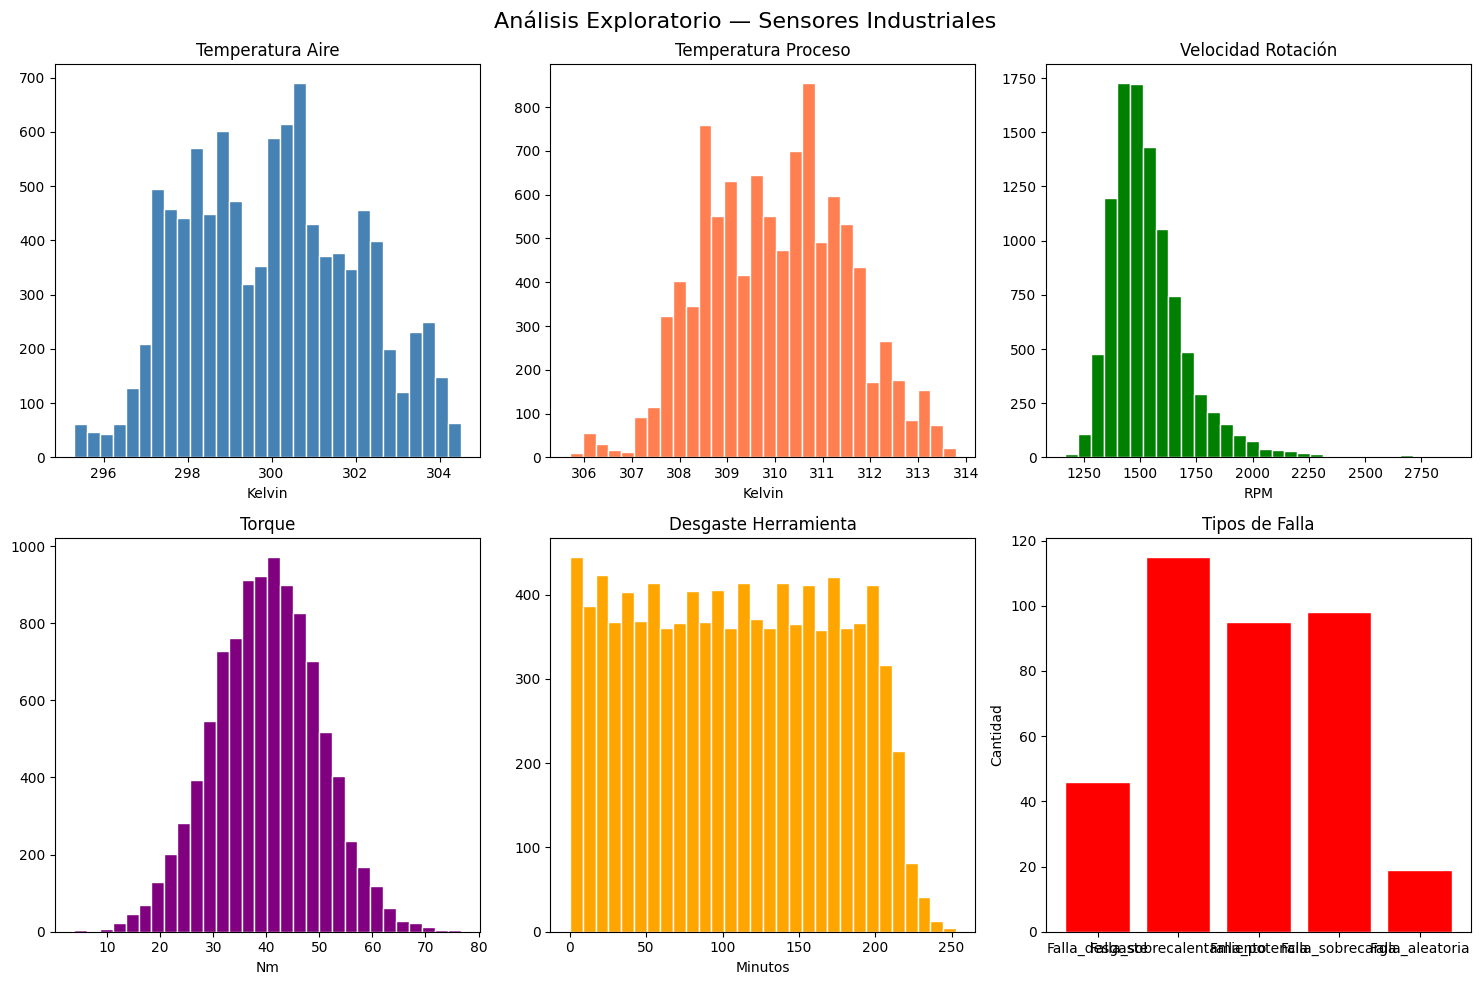


=== DISTRIBUCIÓN DE FALLAS ===
Equipos sin falla: 9661 (96.6%)
Equipos con falla: 339 (3.4%)


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Análisis Exploratorio — Sensores Industriales', fontsize=16)

# Temperatura aire
axes[0,0].hist(df['Air temperature [K]'], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Temperatura Aire')
axes[0,0].set_xlabel('Kelvin')

# Temperatura proceso
axes[0,1].hist(df['Process temperature [K]'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Temperatura Proceso')
axes[0,1].set_xlabel('Kelvin')

# Velocidad rotación
axes[0,2].hist(df['Rotational speed [rpm]'], bins=30, color='green', edgecolor='white')
axes[0,2].set_title('Velocidad Rotación')
axes[0,2].set_xlabel('RPM')

# Torque
axes[1,0].hist(df['Torque [Nm]'], bins=30, color='purple', edgecolor='white')
axes[1,0].set_title('Torque')
axes[1,0].set_xlabel('Nm')

# Desgaste herramienta
axes[1,1].hist(df['Tool wear [min]'], bins=30, color='orange', edgecolor='white')
axes[1,1].set_title('Desgaste Herramienta')
axes[1,1].set_xlabel('Minutos')

# Distribución de fallas
fallas = df[['Falla_desgaste','Falla_sobrecalentamiento','Falla_potencia','Falla_sobrecarga','Falla_aleatoria']].sum()
axes[1,2].bar(fallas.index, fallas.values, color='red', edgecolor='white')
axes[1,2].set_title('Tipos de Falla')
axes[1,2].set_ylabel('Cantidad')

plt.tight_layout()
plt.savefig('analisis_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== DISTRIBUCIÓN DE FALLAS ===")
print(f"Equipos sin falla: {(df['Machine failure']==0).sum()} ({(df['Machine failure']==0).mean()*100:.1f}%)")
print(f"Equipos con falla: {(df['Machine failure']==1).sum()} ({(df['Machine failure']==1).mean()*100:.1f}%)")

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# Variables sensores
X = df[['Air temperature [K]', 'Process temperature [K]',
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

# Balancear el dataset — técnica clave para fallas raras
df_normal = df[y==0]
df_falla  = df[y==1]
df_falla_over = resample(df_falla, replace=True,
                         n_samples=len(df_normal),
                         random_state=42)
df_bal = pd.concat([df_normal, df_falla_over])
X_bal = df_bal[['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y_bal = df_bal['Machine failure']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)

# Entrenar árbol de decisión — igual que en tu trabajo
modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

# Evaluar
y_pred = modelo.predict(X_test)
print("=== RESULTADO DEL MODELO ===")
print(classification_report(y_test, y_pred,
      target_names=['Sin falla','Con falla']))

=== RESULTADO DEL MODELO ===
              precision    recall  f1-score   support

   Sin falla       0.97      0.92      0.95      1942
   Con falla       0.93      0.97      0.95      1923

    accuracy                           0.95      3865
   macro avg       0.95      0.95      0.95      3865
weighted avg       0.95      0.95      0.95      3865



**Precision** — "cuando digo que hay falla, ¿cuántas veces tengo razón?"

Sin falla: 0.97 → cuando el modelo dice "equipo normal", acierta el 97% de las veces
Con falla: 0.93 → cuando dice "hay falla", acierta el 93% de las veces

**Recall** — "de todas las fallas reales, ¿cuántas detecté?"

Sin falla: 0.92 → detecta el 92% de los equipos normales
Con falla: 0.97 → detecta el 97% de las fallas reales ← este es el más importante en industria

**1-score** — el balance entre los dos anteriores

0.95 en ambos → el modelo es parejo, no sacrifica uno por el otro

**Accuracy** — precisión general

0.95 → el modelo acierta el 95% de los casos totales

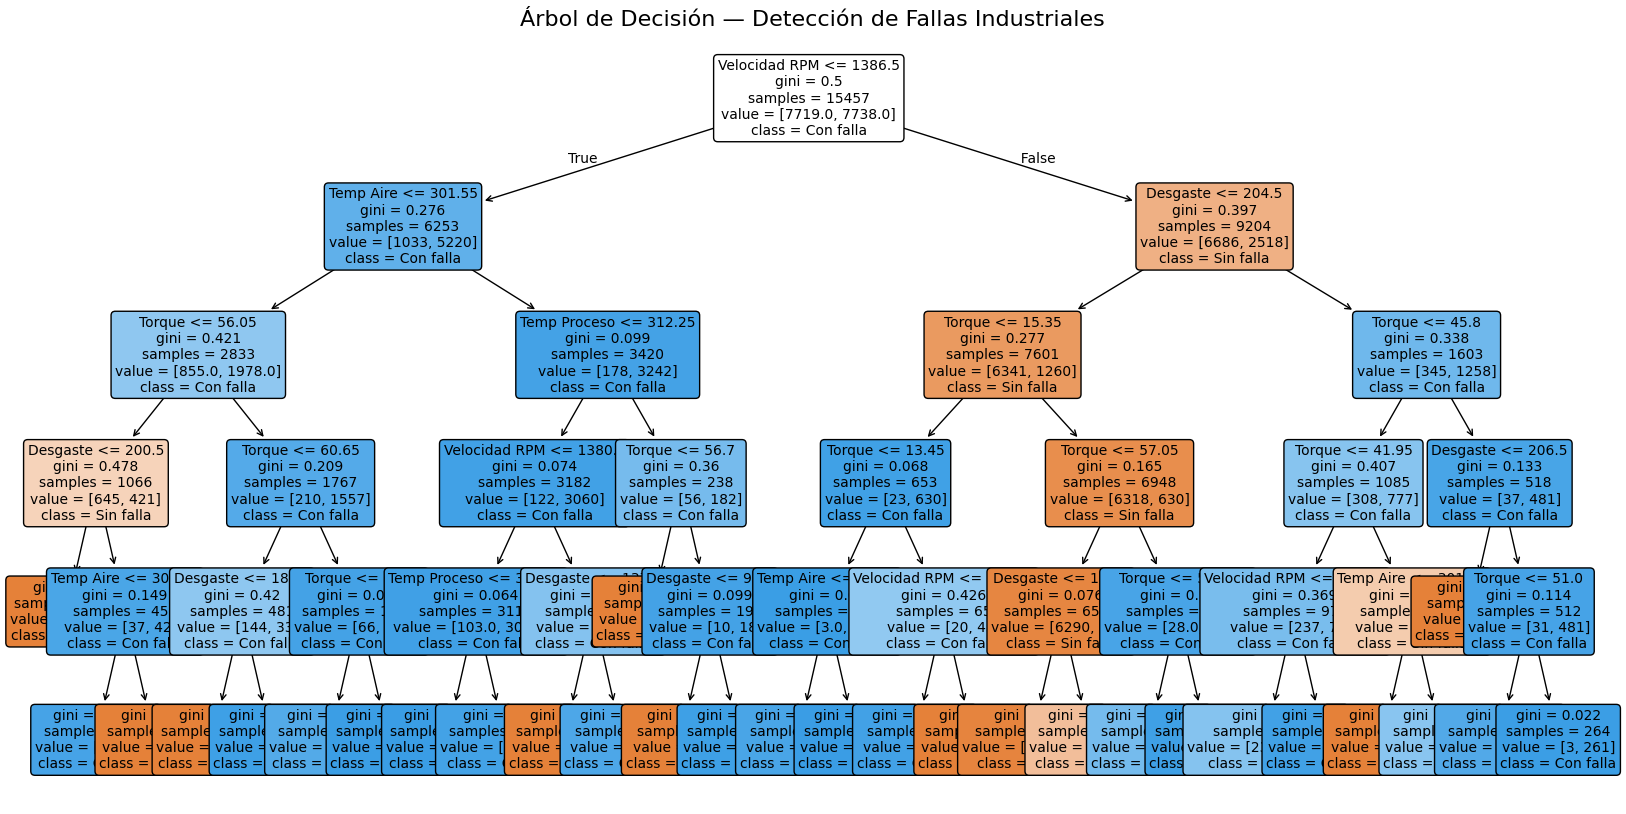

Gráfico guardado correctamente


In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelo,
          feature_names=['Temp Aire', 'Temp Proceso',
                        'Velocidad RPM', 'Torque', 'Desgaste'],
          class_names=['Sin falla', 'Con falla'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árbol de Decisión — Detección de Fallas Industriales', fontsize=16)
plt.savefig('arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado correctamente")

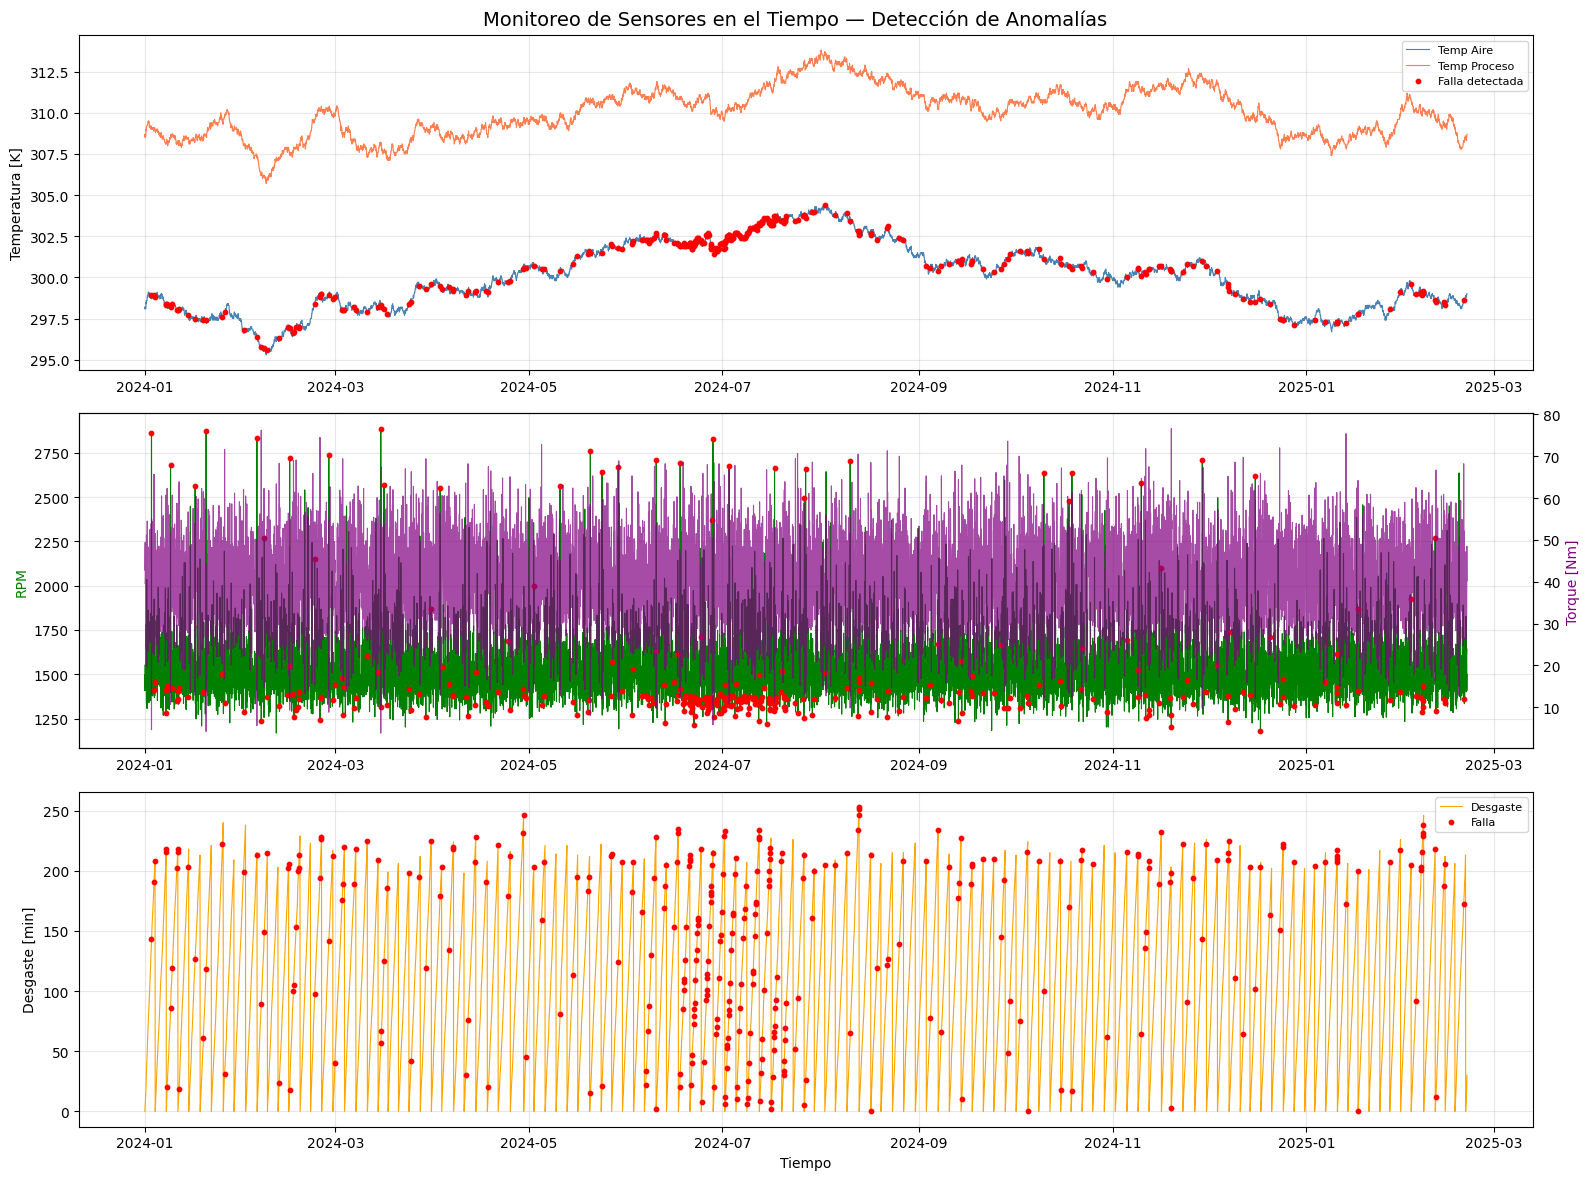

Gráfico guardado correctamente


In [17]:
import pandas as pd

# Crear timestamp — cada fila = 1 hora desde el 1 enero 2024
df['timestamp'] = pd.date_range(start='2024-01-01',
                                 periods=len(df),
                                 freq='h')

# Graficar curva real vs anomalías detectadas
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Monitoreo de Sensores en el Tiempo — Detección de Anomalías',
             fontsize=14)

# Separar fallas para marcarlas
fallas = df[df['Machine failure']==1]

# Gráfico 1 — Temperatura
axes[0].plot(df['timestamp'], df['Air temperature [K]'],
             color='steelblue', linewidth=0.8, label='Temp Aire')
axes[0].plot(df['timestamp'], df['Process temperature [K]'],
             color='coral', linewidth=0.8, label='Temp Proceso')
axes[0].scatter(fallas['timestamp'], fallas['Air temperature [K]'],
                color='red', s=10, zorder=5, label='Falla detectada')
axes[0].set_ylabel('Temperatura [K]')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Gráfico 2 — Velocidad y Torque
axes[1].plot(df['timestamp'], df['Rotational speed [rpm]'],
             color='green', linewidth=0.8, label='Velocidad RPM')
ax2 = axes[1].twinx()
ax2.plot(df['timestamp'], df['Torque [Nm]'],
         color='purple', linewidth=0.8, alpha=0.7, label='Torque Nm')
axes[1].scatter(fallas['timestamp'], fallas['Rotational speed [rpm]'],
                color='red', s=10, zorder=5)
axes[1].set_ylabel('RPM', color='green')
ax2.set_ylabel('Torque [Nm]', color='purple')
axes[1].grid(True, alpha=0.3)

# Gráfico 3 — Desgaste herramienta
axes[2].plot(df['timestamp'], df['Tool wear [min]'],
             color='orange', linewidth=0.8, label='Desgaste')
axes[2].scatter(fallas['timestamp'], fallas['Tool wear [min]'],
                color='red', s=10, zorder=5, label='Falla')
axes[2].set_ylabel('Desgaste [min]')
axes[2].set_xlabel('Tiempo')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_temporales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado correctamente")

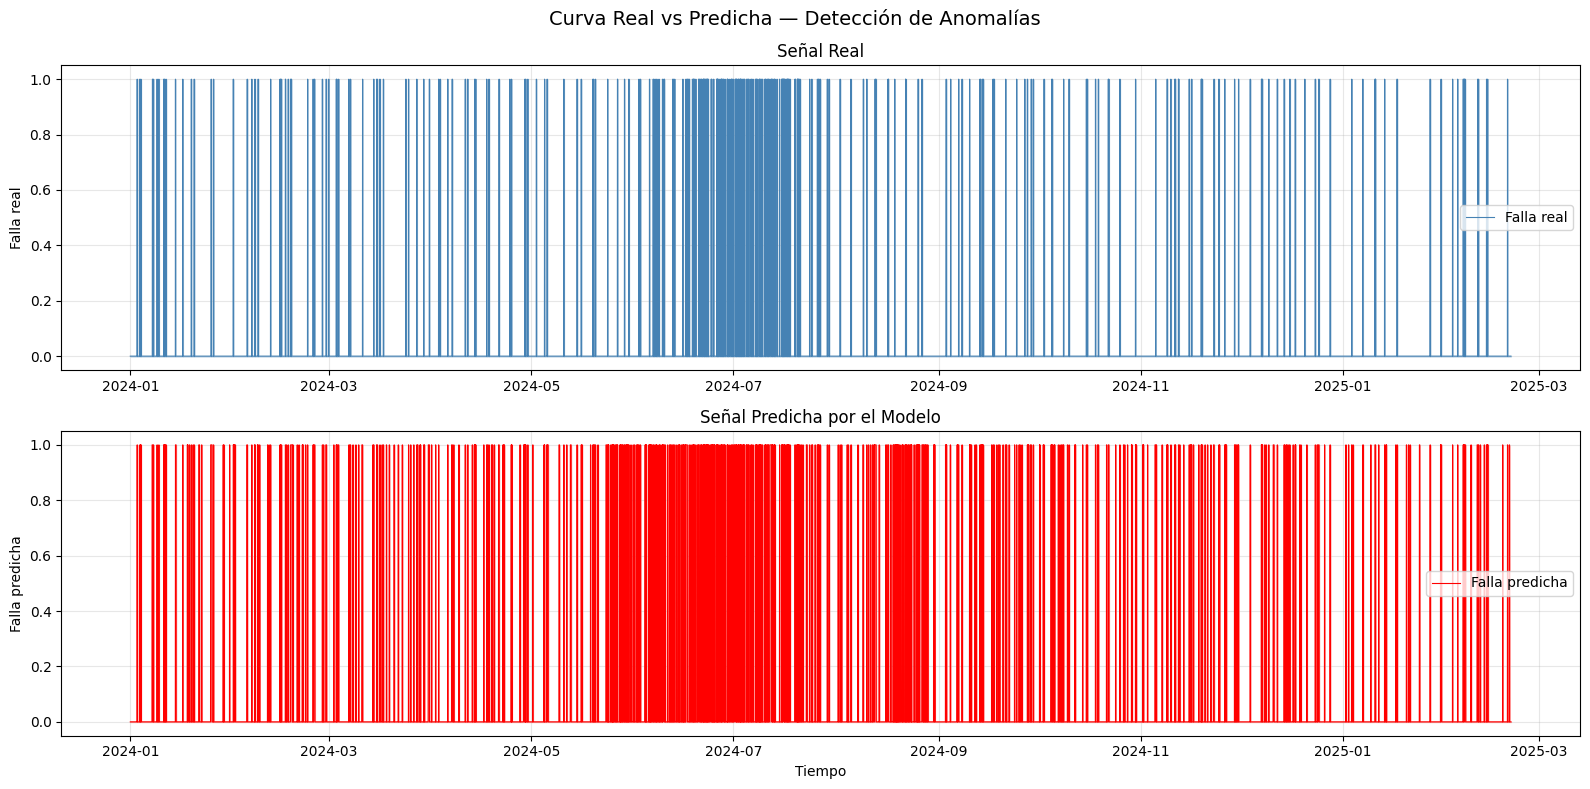


=== RESUMEN FINAL ===
Total registros analizados: 10,000
Fallas reales detectadas: 339
Fallas predichas correctamente: -351
Desviaciones detectadas: 690
Precisión general: 93.1%


In [18]:
# Predecir sobre los datos originales (sin balancear)
X_original = df[['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
df['falla_predicha'] = modelo.predict(X_original)

# Graficar real vs predicha
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Curva Real vs Predicha — Detección de Anomalías', fontsize=14)

# Curva real
axes[0].plot(df['timestamp'], df['Machine failure'],
             color='steelblue', linewidth=0.8, label='Falla real')
axes[0].fill_between(df['timestamp'], df['Machine failure'],
                     alpha=0.3, color='steelblue')
axes[0].set_ylabel('Falla real')
axes[0].set_title('Señal Real')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Curva predicha
axes[1].plot(df['timestamp'], df['falla_predicha'],
             color='red', linewidth=0.8, label='Falla predicha')
axes[1].fill_between(df['timestamp'], df['falla_predicha'],
                     alpha=0.3, color='red')
axes[1].set_ylabel('Falla predicha')
axes[1].set_title('Señal Predicha por el Modelo')
axes[1].set_xlabel('Tiempo')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('real_vs_predicha.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen final
desviaciones = (df['Machine failure'] != df['falla_predicha']).sum()
print(f"\n=== RESUMEN FINAL ===")
print(f"Total registros analizados: {len(df):,}")
print(f"Fallas reales detectadas: {df['Machine failure'].sum()}")
print(f"Fallas predichas correctamente: {df['Machine failure'].sum() - desviaciones}")
print(f"Desviaciones detectadas: {desviaciones}")
print(f"Precisión general: {(1 - desviaciones/len(df))*100:.1f}%")

/tmp/ipykernel_178/885743916.py:37: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_178/885743916.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_178/885743916.py:38: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.savefig('real_vs_predicha.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_178/885743916.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('real_vs_predicha.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

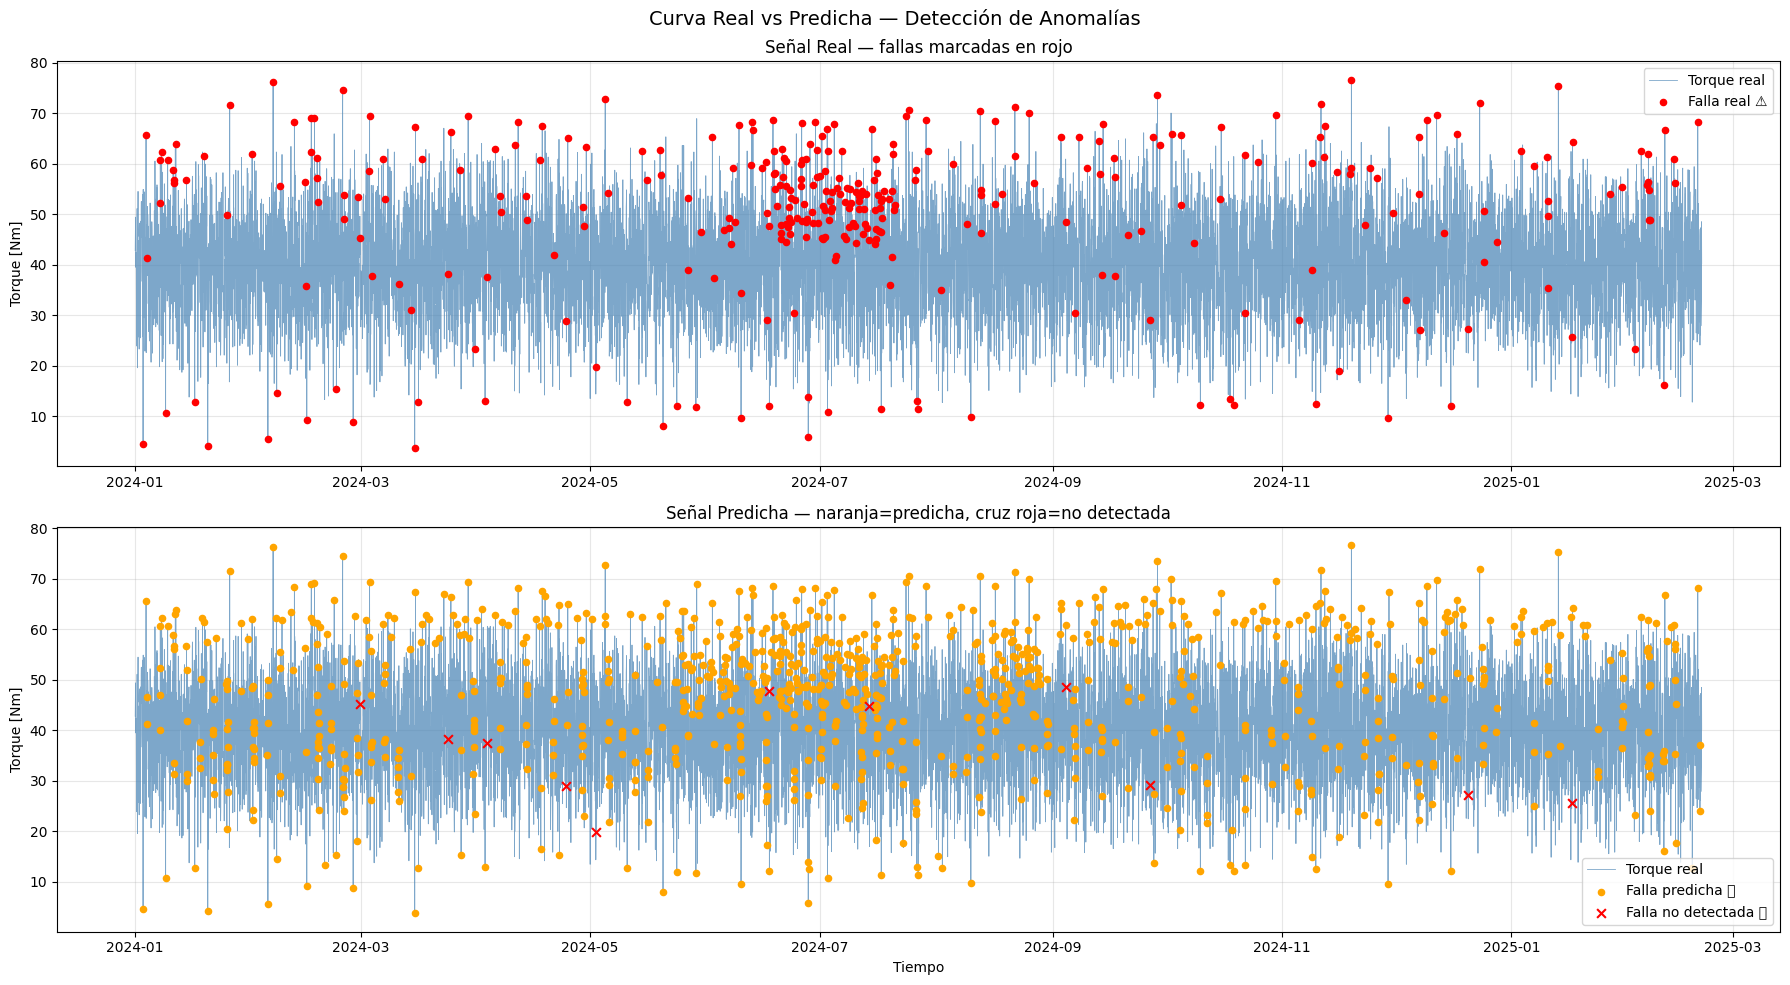


=== RESUMEN FINAL ===
Total registros analizados: 10,000
Fallas reales:              339
Fallas predichas:           1007
Fallas NO detectadas:       11
Precisión general:          93.1%


In [19]:
# Predecir sobre datos originales
X_original = df[['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
df['falla_predicha'] = modelo.predict(X_original)

# Separar puntos
fallas_reales     = df[df['Machine failure']==1]
fallas_predichas  = df[df['falla_predicha']==1]
falsos_negativos  = df[(df['Machine failure']==1) & (df['falla_predicha']==0)]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Curva Real vs Predicha — Detección de Anomalías', fontsize=14)

# Gráfico 1 — Torque con fallas reales marcadas
axes[0].plot(df['timestamp'], df['Torque [Nm]'],
             color='steelblue', linewidth=0.6, label='Torque real', alpha=0.7)
axes[0].scatter(fallas_reales['timestamp'], fallas_reales['Torque [Nm]'],
                color='red', s=20, zorder=5, label='Falla real ⚠️')
axes[0].set_title('Señal Real — fallas marcadas en rojo')
axes[0].set_ylabel('Torque [Nm]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2 — Torque con fallas predichas marcadas
axes[1].plot(df['timestamp'], df['Torque [Nm]'],
             color='steelblue', linewidth=0.6, label='Torque real', alpha=0.7)
axes[1].scatter(fallas_predichas['timestamp'], fallas_predichas['Torque [Nm]'],
                color='orange', s=20, zorder=5, label='Falla predicha 🔮')
axes[1].scatter(falsos_negativos['timestamp'], falsos_negativos['Torque [Nm]'],
                color='red', s=40, zorder=6, marker='x', label='Falla no detectada ❌')
axes[1].set_title('Señal Predicha — naranja=predicha, cruz roja=no detectada')
axes[1].set_ylabel('Torque [Nm]')
axes[1].set_xlabel('Tiempo')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('real_vs_predicha.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== RESUMEN FINAL ===")
print(f"Total registros analizados: {len(df):,}")
print(f"Fallas reales:              {df['Machine failure'].sum()}")
print(f"Fallas predichas:           {df['falla_predicha'].sum()}")
print(f"Fallas NO detectadas:       {falsos_negativos.shape[0]}")
print(f"Precisión general:          {(1-(df['Machine failure'] != df['falla_predicha']).sum()/len(df))*100:.1f}%")